## Solución del problema mediante algoritmo de DPLL 
A continuación intentaremos encontrar un modelo para las reglas utilizando el algoritmo de DPLL

In [2]:
from logica import*   
from grafos import*

In [3]:
g=Grafos()

In [4]:
def filtro(dict_tseitin, regla): 
    h = inorder_to_tree(regla) 
    letras = h.letras()
    for letter in dict_tseitin.copy(): 
        if letter not in letras: 
            del dict_tseitin[letter] 

    return dict_tseitin 

## Primera regla
Empezaremos con la primera regla, la cual nos dice que el recorrido debe comenzar obligatoriamente en el nodo H:

In [7]:
%%time 
#REGLA 1
A1 = g.reglas[0]
ts1 = tseitin(A1)   
r1 = dpll(ts1, {}) 
I1 = filtro(r1[1], A1)


CPU times: total: 15.6 ms
Wall time: 9.91 ms


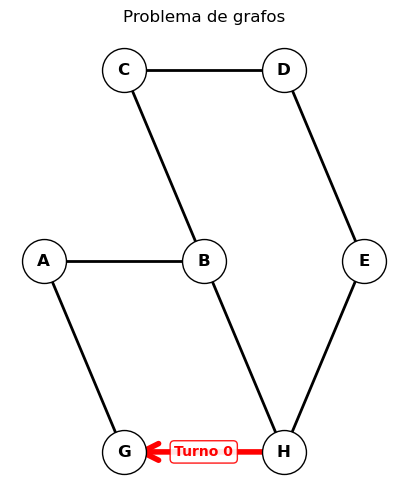

In [8]:
g.visualizar_grafo(I1)

Tiempo de ejecución: 15.6ms

La primera regla se representa correctamente pues empieza desde el turno H en el turno 0

## Segunda regla:  
Proseguiremos con la segunda regla, la cual dice que el ultimo recorrido debe ser a B. Es decir darse en el turno 7.

In [9]:
%%time  
#REGLA 2
A2 = g.reglas[1] 
ts2 = tseitin(A2)   
r2 = dpll(ts2, {}) 
I2 = filtro(r2[1], A2) 


CPU times: total: 15.6 ms
Wall time: 10.5 ms


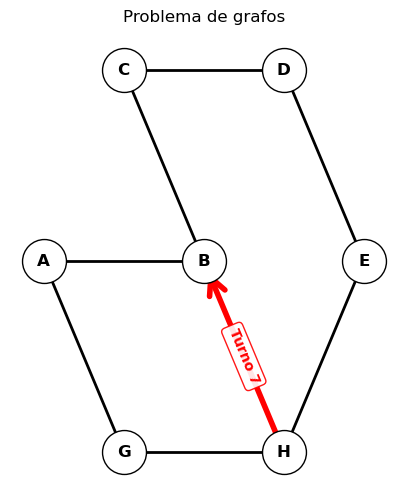

In [10]:
g.visualizar_grafo(I2)

Tiempo de ejecución: 15.6ms

Observe que este modelo es correcto pues el se hace un recorrido a B desde el turno 7

## Regla 3 
La siguiente regla hace que en el problema cada arista sea transitada al menos una vez. 

In [13]:
%%time  
#Regla 3 
A3 = g.reglas[2] 
ts3 = tseitin(A3)   
r3 = dpll(ts3, {}) 
I3 = filtro(r3[1], A3) 


CPU times: total: 15.6 ms
Wall time: 36.8 ms


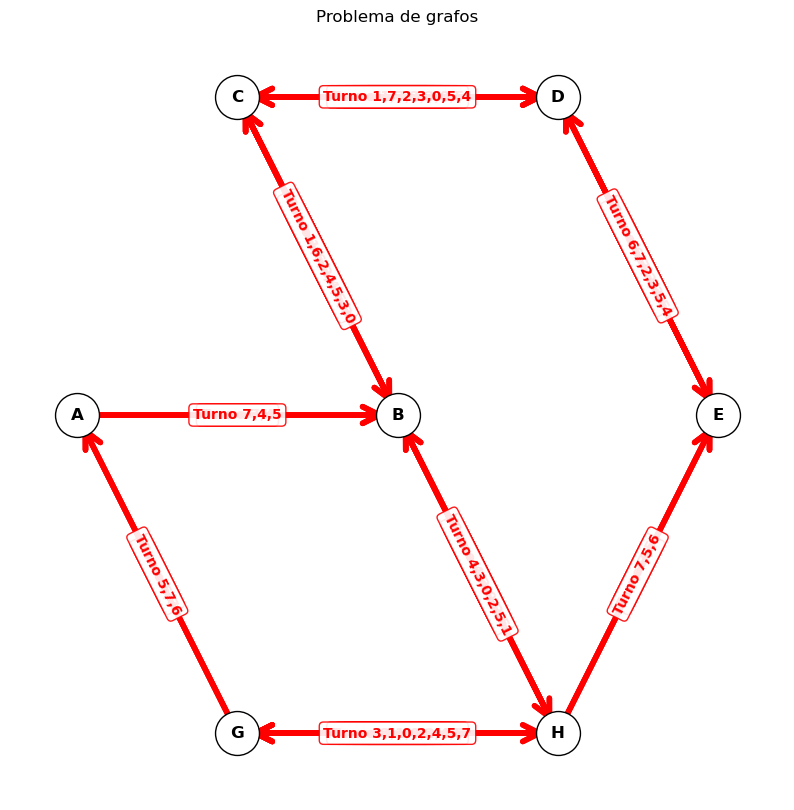

In [14]:
g.visualizar_grafo(I3,custom_size=(10,10))

Tiempo de ejecución: 15.6ms

Observe que se cumple esta condición pues todas las aristas son transitadas en al menos un turno.

## Regla 4 
La regla 4 hace que ninguna arista pueda ser recorrida más de una vez durante la secuencia. 

In [16]:
%%time  
#Regla 4
A4 = g.reglas[3] 
ts4 = tseitin(A4)   
r4 = dpll(ts4, {}) 
I4 = filtro(r4[1], A4)


CPU times: total: 14.7 s
Wall time: 15.4 s


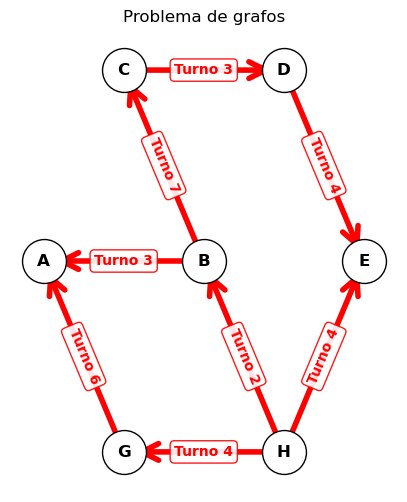

In [17]:
g.visualizar_grafo(I4)

Tiempo de ejecución: 15.4s

Observe que el modelo es acorde a la regla pues no hay ninguna arista que sea recorrida en más de un turno

## Regla 5: 
El vértice de salida en el turno $t$ debe ser el mismo que el vértice de llegada del turno t-1.

In [18]:
%%time  
#Regla 5
A5 = g.reglas[4] 
ts5 = tseitin(A5)   
r5 = dpll(ts5, {}) 
I5 = filtro(r5[1], A5)

CPU times: total: 141 ms
Wall time: 165 ms


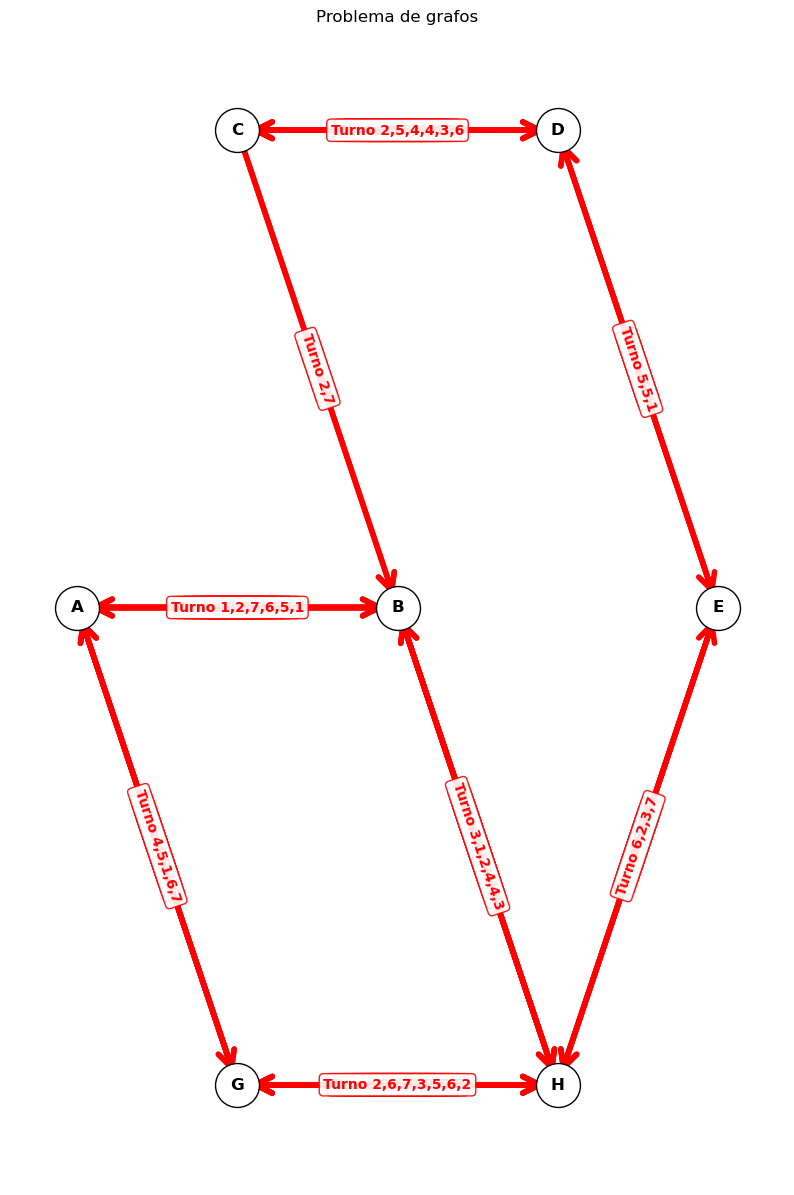

In [16]:
g.visualizar_grafo(I5,custom_size=(10,15))

Tiempo de ejecución: 141ms

Observe que el modelo satisface la quinta regla, pues siempre que en el turno t−1 se llega a un vértice j, en el turno t existe un movimiento que sale desde dicho vértice. De esta manera se preserva la continuidad del recorrido. Aunque el grafo se visualiza de forma no dirigida, las flechas representan las direcciones reales utilizadas por el modelo.

## Solución al problema 
Ahora intentaremos encontrar un modelo para solucionar el problema uniendo todas las reglas definidas y utilizando el algoritmo de DPLL

CPU times: total: 0 ns
Wall time: 5.48 μs


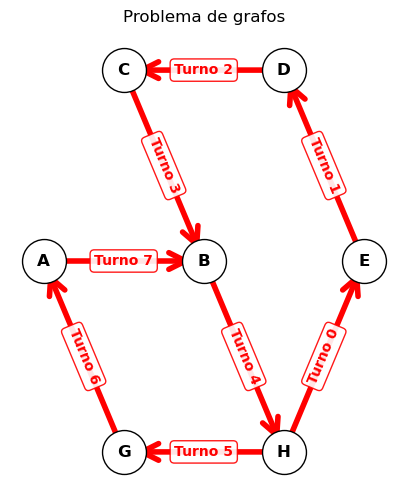

In [ ]:
%time
reglas = Ytoria([g.reglas[2], g.reglas[3],g.reglas[0],g.reglas[1],g.reglas[4]])
A = reglas  
ts = tseitin(A) 
r = dpll(ts,{})
I = filtro(r[1], A) 
g.visualizar_grafo(I)

Tiempo de ejecución: 4m 36s

¡Hemos encontrado una solución! Observe que este modelo representa un recorrido de H a B recorriendo cada arista exactamente una vez.